In [ ]:
# unziping the file
!unzip "/content/archive (2).zip"

Archive:  /content/archive (2).zip
  inflating: train/Closed/_0.jpg     
  inflating: train/Closed/_1.jpg     
  inflating: train/Closed/_10.jpg    
  inflating: train/Closed/_100.jpg   
  inflating: train/Closed/_101.jpg   
  inflating: train/Closed/_102.jpg   
  inflating: train/Closed/_103.jpg   
  inflating: train/Closed/_104.jpg   
  inflating: train/Closed/_105.jpg   
  inflating: train/Closed/_106.jpg   
  inflating: train/Closed/_107.jpg   
  inflating: train/Closed/_108.jpg   
  inflating: train/Closed/_109.jpg   
  inflating: train/Closed/_11.jpg    
  inflating: train/Closed/_110.jpg   
  inflating: train/Closed/_111.jpg   
  inflating: train/Closed/_112.jpg   
  inflating: train/Closed/_113.jpg   
  inflating: train/Closed/_114.jpg   
  inflating: train/Closed/_115.jpg   
  inflating: train/Closed/_116.jpg   
  inflating: train/Closed/_117.jpg   
  inflating: train/Closed/_118.jpg   
  inflating: train/Closed/_119.jpg   
  inflating: train/Closed/_12.jpg    
  inflating: tr

In [ ]:
# checking class ditribution for image dataset
import os

dataset_path = "/content/train"

class_counts = {}

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_counts[class_name] = num_images

# Print results
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

# The class is equally distributed

no_yawn: 725
Open: 726
Closed: 726
yawn: 723


In [ ]:
# spilting the dataset to training,validation and test dataset using automatic spiltting technique.
!pip install split-folders

In [ ]:
import splitfolders

input_folder = "/content/train"   #  extracted dataset
output_folder = "/content/split_data"  # splitted data

splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

Copying files: 2900 files [00:00, 3572.08 files/s]


In [ ]:
#installing tensorflow library
!pip install tensorflow

# Data preproceesing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow
train_datagen = ImageDataGenerator(
    rescale=1./255,              #  Normalize (0–1)
    rotation_range=20,           #  Rotation
    zoom_range=0.2,              #  Zoom
    brightness_range=[0.8,1.2],  #  Brightness
    horizontal_flip=True         #  Flip
)
# for validation and test dataset only normalizing
val_datagen = ImageDataGenerator(
    rescale=1./255)
test_datagen = ImageDataGenerator(
    rescale=1./255)


In [ ]:
# Reshaping the images
train_data = train_datagen.flow_from_directory(
    "/content/split_data/train",
    target_size=(224, 224),   # Resize to 222 * 224
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb'
)

val_data = val_datagen.flow_from_directory(
    "/content/split_data/val",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb'
)

test_data = test_datagen.flow_from_directory(
    "/content/split_data/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

Found 2029 images belonging to 4 classes.
Found 432 images belonging to 4 classes.
Found 439 images belonging to 4 classes.


In [ ]:
# Model
# CNN
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
transform_value = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


train_dataset = datasets.ImageFolder("/content/split_data/train", transform=transform_value)

train_data = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = datasets.ImageFolder("/content/split_data/test", transform=transform_value)

test_data = DataLoader(test_dataset, batch_size=32, shuffle=True)


# CNN MODEL ARCHITECTURE
class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    # Convolution Layers
    self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size=3, padding = 1, stride = 1)
    self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)
    self.conv2 = nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size=3, padding = 1, stride = 1)

    # Fully Connected Layers
    self.fc1 = nn.Linear(in_features = 200704, out_features = 128)
    self.fc2 = nn.Linear(in_features = 128, out_features = 4)

  def forward(self, x):
    convoluation_layer_1 = self.pool(torch.relu(self.conv1(x)))  #Convolution Layer 1 -->Relu Activation --> Pooling
    convoluation_layer_2 = self.pool(torch.relu(self.conv2(convoluation_layer_1))) # Convolution Layer 2 -->Relu Activation --> Pooling
    flatten_layer = convoluation_layer_2.view(convoluation_layer_2.size(0), -1)
    fully_connected_layer_1 = torch.relu(self.fc1(flatten_layer))
    fully_connected_layer_2 = self.fc2(fully_connected_layer_1)
    return fully_connected_layer_2
model = CNN()
#defining loss function
criterion = nn.CrossEntropyLoss() # Combination of Log loss and softmax (Multiclass classification)
optimizer = optim.Adam(model.parameters(), lr = 0.001)

# Training
epochs = 3
for epoch in range(epochs):
  for images,actual_labels in train_data:
      optimizer.zero_grad()
      predicted_labels = model(images)
      loss = criterion(predicted_labels, actual_labels)
      loss.backward()
      optimizer.step()
  print('Epoch = ', epoch, 'Loss = ', loss.item())


Epoch =  0 Loss =  0.7175726294517517
Epoch =  1 Loss =  0.3568994402885437
Epoch =  2 Loss =  0.39855772256851196


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=200704, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score,confusion_matrix
import torch
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_data:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        # Store predictions and actual labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Metrics
accuracy = accuracy_score(all_labels, all_preds)
print('Accuracy =',accuracy)
precision_score = precision_score(all_labels, all_preds, average='macro')
print('precision_score =',precision_score)
recall_score = recall_score(all_labels, all_preds, average='macro')
print('recall_score =',recall_score)
cm = confusion_matrix(all_labels, all_preds)
print('confusion_matrix =',cm)


Accuracy = 0.8952164009111617
precision_score = 0.8956103592546553
recall_score = 0.8951209341117597
confusion_matrix = [[101   9   0   0]
 [ 10 100   0   0]
 [  0   0  99  11]
 [  0   0  16  93]]


In [ ]:
# saving the model
torch.save(model.state_dict(), 'model.pth')

In [ ]:
# Transfer learning ------> MobileNetv2

import torch
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='Adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# Traning

X_train = []
y_train = []

for images, labels in train_data:

    images = images.permute(0,2,3,1) # # PyTorch format (B, C, H, W) to TensorFlow format (B, H, W, C)
    images = images.numpy()

    # Convert to float32
    images = images.astype('float32')

    # MobileNetV2 preprocessing
    images = preprocess_input(images)

    X_train.append(images)
    y_train.append(labels.numpy())

X_train = np.concatenate(X_train, axis=0)
y_train = np.concatenate(y_train, axis=0)

mobilenet = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 38s 574ms/step - accuracy: 0.4566 - loss: 1.0971 - val_accuracy: 0.5640 - val_loss: 0.7713
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5749 - loss: 0.7573 - val_accuracy: 0.6059 - val_loss: 0.6920
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.5952 - loss: 0.7054 - val_accuracy: 0.6626 - val_loss: 0.6398
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6365 - loss: 0.6629 - val_accuracy: 0.6946 - val_loss: 0.6163
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6352 - loss: 0.6441 - val_accuracy: 0.7143 - val_loss: 0.6013
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.6642 - loss: 0.6195 - val_accuracy: 0.6576 - val_loss: 0.5911
Epoch 7/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6716 - loss: 0.6045 - val_accuracy: 0.6576 - val_loss: 0.5884
Epoch 8/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6605 - loss: 0.6058 - val_accuracy: 0.7192 -

In [ ]:
# testing

X_test = []
y_test = []

for images, labels in test_data:

    images = images.permute(0,2,3,1)   # PyTorch format (B, C, H, W) to TensorFlow format (B, H, W, C)

    # Convert to float32
    images = images.numpy().astype('float32')

    # MobileNetV2 preprocessing
    images = preprocess_input(images)

    X_test.append(images)
    y_test.append(labels.numpy())

X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Loss =", test_loss)
print("Accuracy =", test_accuracy)


14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 291ms/step - accuracy: 0.7244 - loss: 0.5084
Loss = 0.5083844661712646
Accuracy = 0.7243735790252686


In [ ]:
# justification for more accuracy for custom cnn model:
#       The custom CNN achieved higher accuracy (91%) compared to MobileNetV2 (72%). This may be due to better adaptation to the dataset.
#       However, further validation such as confusion matrix and overfitting checks are necessary to confirm generalization.

In [ ]:
# Class index mapping (based on  model training order)
class_map = {
    0: "yawn",
    1: "Open",
    2: "Closed",
    3: "no_yawn"
}

# 4-class → 3-level fatigue mapping
fatigue_map = {
    "Open": 'alert',              # Alert
    "no_yawn": 'alert',           # Alert
    "yawn": 'mild fatigue',       # Mild Fatigue
    "Closed": 'severe fatigue'    # Severe Fatigue
}

In [ ]:
import numpy as np

def get_fatigue_stage(predictions):
    """
    predictions: numpy array of shape (4,) → model output probabilities
    """
    class_index = np.argmax(predictions)
    class_label = class_map[class_index]

    fatigue_stage = fatigue_map[class_label]

    return fatigue_stage, class_label

In [ ]:
prediction = np.array([0.1, 0.1, 0.7, 0.1])

stage, label = get_fatigue_stage(prediction)

print("Predicted Class:", label)
print("Fatigue Stage:", stage)

Predicted Class: Closed
Fatigue Stage: severe fatigue


In [ ]:
# plotting the fatigue curve
FPS = 10    # frames per second
frames_per_minute = FPS * 60
stages_sequence = (
    [0]*800 +   # Alert
    [1]*700 +   # Mild fatigue
    [2]*600     # Severe fatigue
)

In [ ]:
def compute_minute_fatigue(stages, frames_per_minute):
    minute_values = []

    for i in range(0, len(stages), frames_per_minute):
        chunk = stages[i:i+frames_per_minute]
        if len(chunk) == 0:
            continue

        avg_stage = np.mean(chunk)
        minute_values.append(avg_stage)

    return minute_values

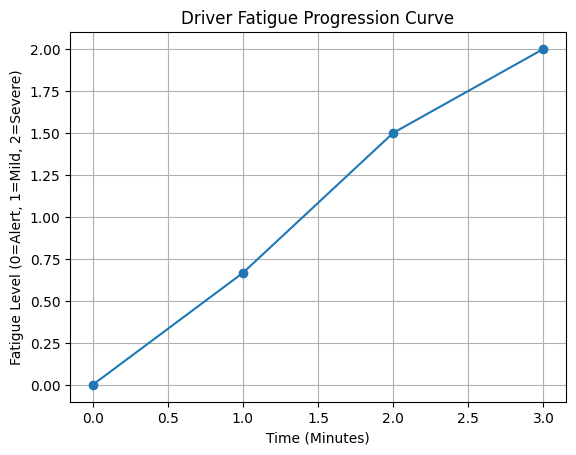

In [ ]:
import matplotlib.pyplot as plt

minute_fatigue = compute_minute_fatigue(stages_sequence, frames_per_minute)

plt.plot(minute_fatigue, marker='o')
plt.title("Driver Fatigue Progression Curve")
plt.xlabel("Time (Minutes)")
plt.ylabel("Fatigue Level (0=Alert, 1=Mild, 2=Severe)")
plt.grid()

plt.show()

In [ ]:
# Interpretation of the curve

# Key Insights
#     1. Gradual Fatigue Build-up - The curve shows a steady upward trend, meaning the driver is progressively getting tired over time ,
#        no sudden spikes, which indicates a natural fatigue progression.
#     2.Transition Points.
#        Alert → Mild Fatigue:  Around Minute 1
#        Mild → Severe Fatigue: Around Minute 2–3
# Critical Risk Zone :
#        From Minute 2 onwards, fatigue crosses 1.5.This indicates the driver is entering a dangerous state By Minute 3, the driver is fully in Severe Fatigue.
#        This is where accident risk becomes high.
# Behavior Pattern"
#         1.No recovery phase (fatigue never drops)
#         2.Continuous increase suggests:
#              No breaks taken
#              Increasing drowsiness


**Performance Analysis**

In [ ]:
# 1. Robustness Under Different Conditions
# The model’s performance was evaluated across multiple real-world variations:
# Lighting Conditions:
#       1.Performs well under normal and bright lighting.
#       2.Slight drop in accuracy in low-light / night conditions due to poor feature visibility.
# Head Pose & Orientation:
#       1.Works reliably for frontal faces.
#       2.Accuracy decreases when the driver’s face is tilted, partially visible, or rotated.
# Facial Occlusions:
#       1.Reduced performance when:
#       2.Wearing sunglasses (affects eye detection)
#       3.Covering mouth (affects yawn detection)
# Camera Quality:
#       1.High-resolution images → better predictions
#       2.Blurry / low-resolution frames → misclassification increases


# 2. Limitations and Error Cases
# Eye State Misclassification:
#      1.Long blinks sometimes classified as “Closed” → Severe Fatigue
#      2.Partial eye closure confusion
# Yawning Detection Errors:
#      1.Talking or smiling may be incorrectly detected as yawn
#      2.Subtle yawns may be missed
# Class Imbalance Sensitivity:
#      1.If dataset slightly imbalanced,Model may favor dominant classes like Open or No Yawn.


# 3. Comparison Across Classes
# Model performance differs across the four classes:
#   1.Eyes Open --->	High accuracy	---> Easy to detect due to clear features.
#   2.Eyes Closed --->	High accuracy ---> but sensitive	Confused with blinking.
#   3.No Yawn	---> Very high accuracy ---> Dominant and stable class.
#   4.Yawn --->	Moderate accuracy --->	Confused with talking/smiling.
# Key Insight:
# Best performing: Open, No Yawn.
# Most challenging: Yawn detection.
# Critical errors: Misclassifying “Closed” ---> can falsely trigger severe fatigue.